# 📊 Notebook 01 — Exploratory Data Analysis (EDA)
### Quality-Aware FER Project

**Dataset:** Folder `dataset/` dengan struktur `train/ validation/ test/`
**Kelas:** 8 emosi — angry, contempt, disgust, fear, happy, neutral, sad, suprise

## 🔧 Auto-Install Dependencies
*Jalankan cell ini sekali jika ada ModuleNotFoundError*

In [1]:
import subprocess, sys

_REQUIRED = [
    "opencv-python",   # cv2
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "Pillow",
    "scikit-learn",
    "tqdm",
    "scipy",
    "pyyaml",
]

_missing = []
for pkg in _REQUIRED:
    mod = pkg.replace("-", "_").split(">=")[0].split("==")[0]
    # map package name → import name
    _import_name = {"opencv_python": "cv2", "Pillow": "PIL", "pyyaml": "yaml",
                    "scikit_learn": "sklearn"}.get(mod, mod)
    try:
        __import__(_import_name)
    except ImportError:
        _missing.append(pkg)

if _missing:
    print(f"📦 Installing missing packages: {_missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + _missing + ["-q"])
    print("✅ Done! Please RESTART the kernel, then re-run from Cell 1.")
else:
    print(f"✅ All packages available. Python: {sys.executable}")

✅ All packages available. Python: d:\BIG-Data\tuber\.venv\Scripts\python.exe


In [2]:
import sys, os, cv2, numpy as np, pandas as pd
import matplotlib
# Hanya set Agg backend jika tidak dijalankan dari Jupyter/IPython
is_jupyter = False
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        is_jupyter = True
except ImportError:
    pass

if not is_jupyter:
    matplotlib.use("Agg")  # script mode: simpan file saja
import matplotlib.pyplot as plt
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

# Root project = satu direktori di atas notebooks/
# Temukan ROOT project secara robust (baik jika dijalankan dari folder 'notebooks' maupun root project)
current_path = Path(".").resolve()
if (current_path / "src").exists() and (current_path / "configs").exists():
    ROOT = current_path
elif (current_path.parent / "src").exists() and (current_path.parent / "configs").exists():
    ROOT = current_path.parent
else:
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

plt.style.use("dark_background")
sns.set_palette("husl")
SAVE_DIR = ROOT / "results" / "plots" / "eda"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ROOT = ROOT / "dataset"
SPLITS       = ["train", "validation", "test"]

# 8 kelas sesuai nama folder
EMOTION_CLASSES = ["angry", "contempt", "disgust", "fear", "happy", "neutral", "sad", "suprise"]
COLORS = ["#ef4444","#a16207","#a855f7","#f97316","#22c55e","#94a3b8","#3b82f6","#eab308"]

print(f"✅ Root project  : {ROOT}")
print(f"📁 Dataset path  : {DATASET_ROOT}")
print(f"📁 EDA plots     : {SAVE_DIR}")

✅ Root project  : D:\BIG-Data\tuber
📁 Dataset path  : D:\BIG-Data\tuber\dataset
📁 EDA plots     : D:\BIG-Data\tuber\results\plots\eda


## 1. Scan Dataset & Hitung Jumlah Sampel

In [3]:
records = []
for split in SPLITS:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        print(f"⚠️  Not found: {split_dir}")
        continue
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        imgs = list(cls_dir.glob("*.png")) + list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg"))
        for img_path in imgs:
            records.append({
                "path":    str(img_path),
                "emotion": cls_dir.name.lower(),
                "split":   split,
            })

df = pd.DataFrame(records)
print(f"\n✅ Total samples: {len(df):,}")
for split in SPLITS:
    n = len(df[df["split"]==split])
    print(f"   {split:<12}: {n:,}")

print(f"\nClasses found: {sorted(df['emotion'].unique())}")


✅ Total samples: 75,914
   train       : 64,000
   validation  : 8,341
   test        : 3,573

Classes found: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']


## 2. Distribusi Kelas per Split

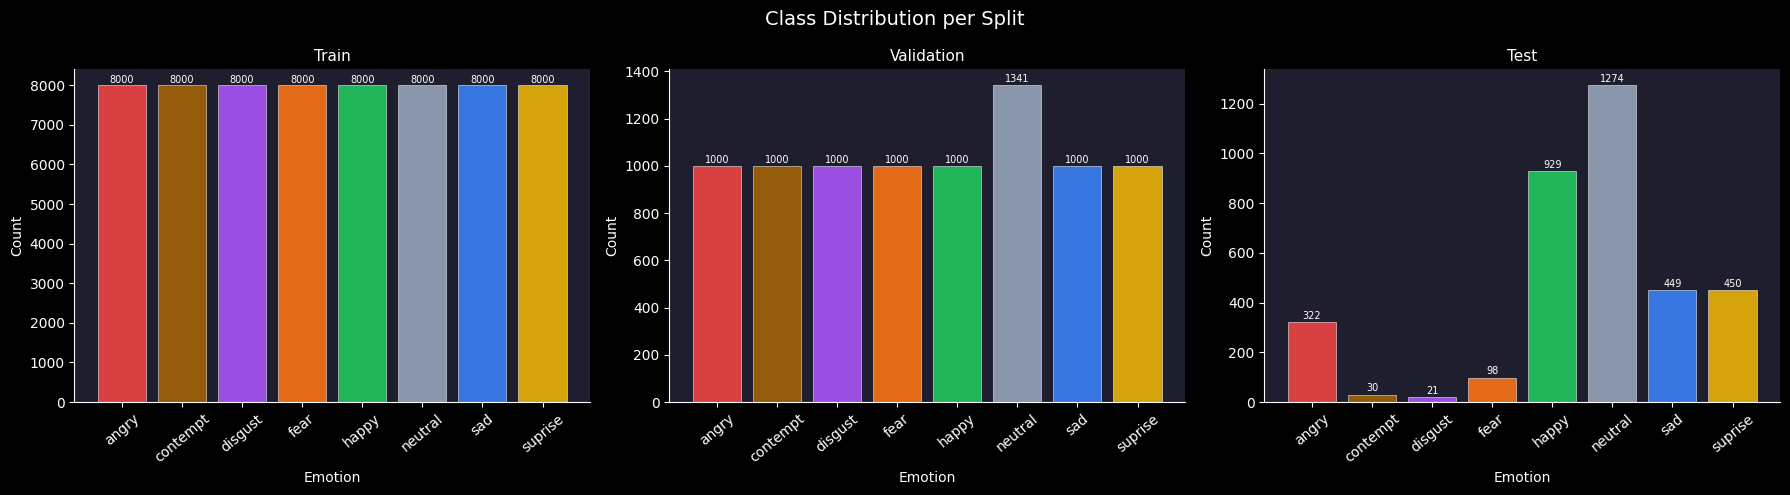

✅ Saved: D:\BIG-Data\tuber\results\plots\eda/01_class_distribution.png


In [4]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(18, 5))
fig.suptitle("Class Distribution per Split", fontsize=14, color="white")

for ax, split in zip(axes, SPLITS):
    sub  = df[df["split"]==split]
    cnts = sub["emotion"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
    bars = ax.bar(cnts.index, cnts.values,
                  color=COLORS[:len(cnts)], edgecolor="white", linewidth=0.4, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="white")
    ax.set_title(split.capitalize(), color="white", fontsize=11)
    ax.set_xlabel("Emotion", color="white"); ax.set_ylabel("Count", color="white")
    ax.tick_params(axis="x", rotation=40, colors="white"); ax.tick_params(axis="y", colors="white")
    ax.set_facecolor("#1e1e2e")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR/"01_class_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"✅ Saved: {SAVE_DIR}/01_class_distribution.png")

## 3. Imbalance Analysis

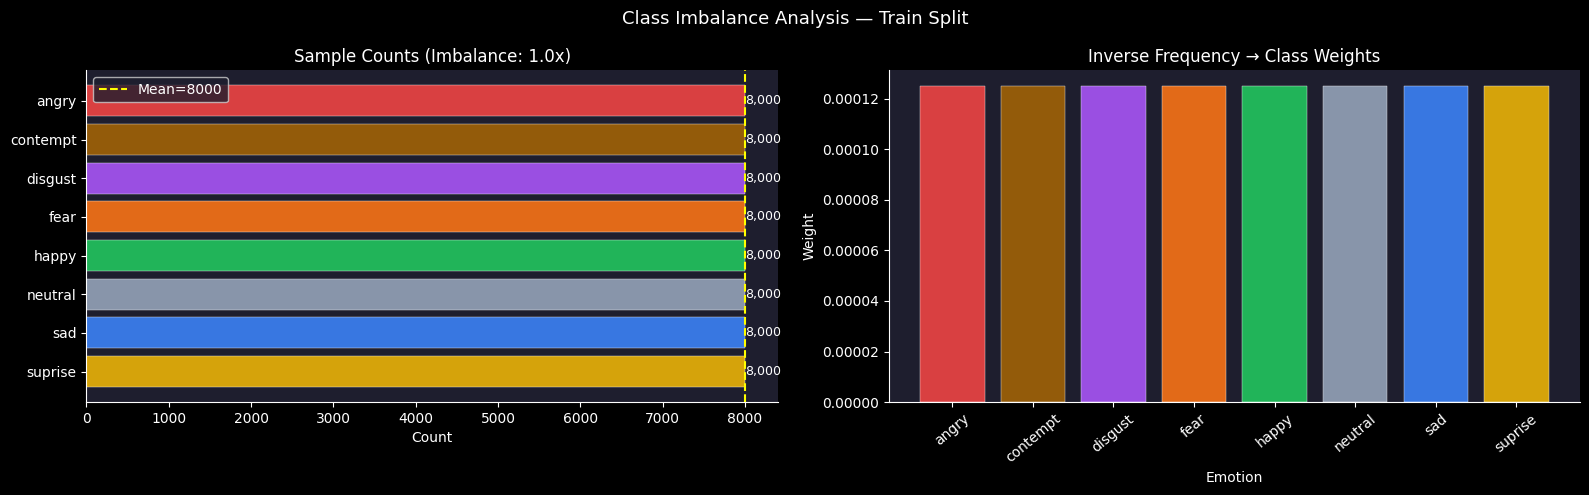

Imbalance ratio: 1.00x
Max : angry (8,000)
Min : angry (8,000)


In [5]:
train_counts = df[df["split"]=="train"]["emotion"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)
max_c = train_counts.max(); min_c = train_counts[train_counts>0].min()
imbalance_ratio = max_c / min_c

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Class Imbalance Analysis — Train Split", fontsize=13, color="white")

# Horizontal bar
ax = axes[0]
bars = ax.barh(train_counts.index[::-1], train_counts.values[::-1],
               color=COLORS[::-1], edgecolor="white", linewidth=0.3, alpha=0.9)
for bar in bars:
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", ha="left", color="white", fontsize=9)
ax.set_title(f"Sample Counts (Imbalance: {imbalance_ratio:.1f}x)", color="white")
ax.set_xlabel("Count", color="white"); ax.tick_params(colors="white")
ax.set_facecolor("#1e1e2e"); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.axvline(train_counts.mean(), color="yellow", linestyle="--", linewidth=1.5,
           label=f"Mean={train_counts.mean():.0f}")
ax.legend(facecolor="#1e1e2e", labelcolor="white")

# Class weights
weights = (1.0 / (train_counts + 1e-6)).sort_values(ascending=False)
ax2 = axes[1]
ax2.bar(weights.index, weights.values,
        color=[COLORS[EMOTION_CLASSES.index(e)] for e in weights.index],
        edgecolor="white", linewidth=0.3, alpha=0.9)
ax2.set_title("Inverse Frequency → Class Weights", color="white")
ax2.set_xlabel("Emotion"); ax2.set_ylabel("Weight"); ax2.tick_params(axis="x", rotation=40, colors="white")
ax2.tick_params(axis="y", colors="white"); ax2.set_facecolor("#1e1e2e")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR/"02_imbalance_analysis.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"Imbalance ratio: {imbalance_ratio:.2f}x")
print(f"Max : {train_counts.idxmax()} ({max_c:,})")
print(f"Min : {train_counts[train_counts>0].idxmin()} ({min_c:,})")

## 4. Sample Images per Kelas

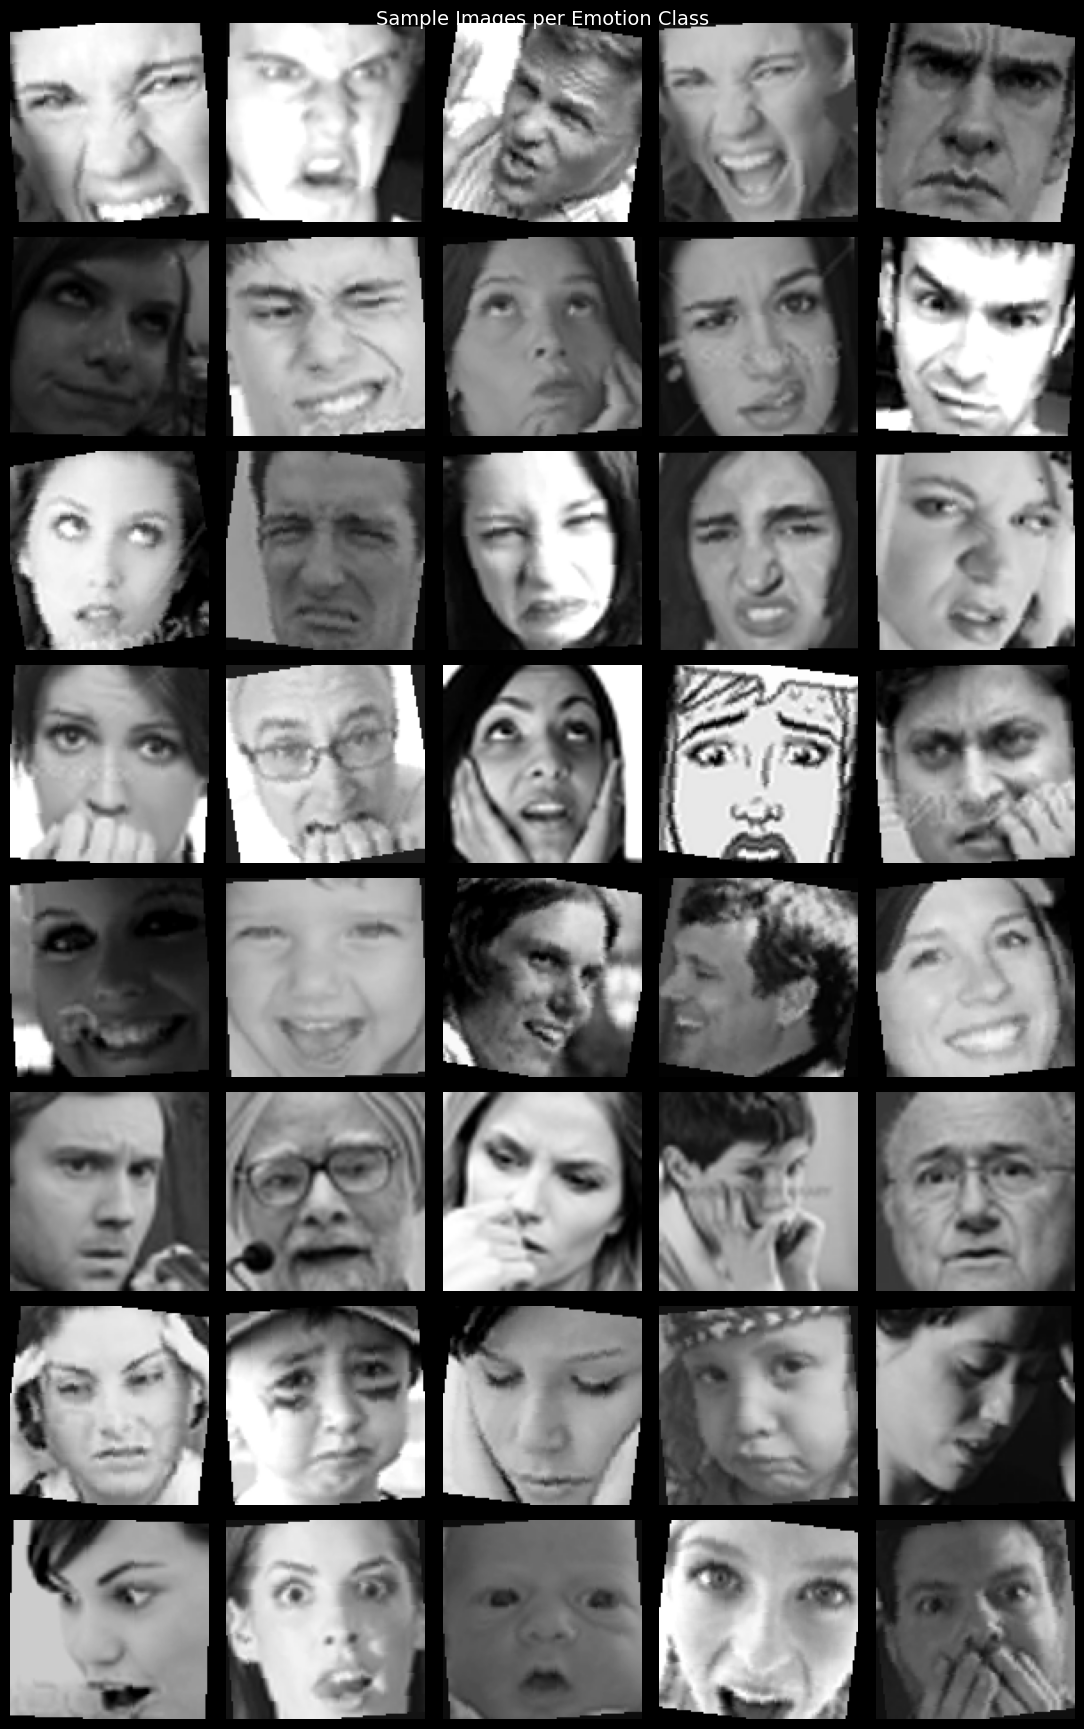

In [6]:
N_SAMPLES = 5
train_df  = df[df["split"]=="train"].reset_index(drop=True)

fig, axes = plt.subplots(len(EMOTION_CLASSES), N_SAMPLES, figsize=(N_SAMPLES*2.2, len(EMOTION_CLASSES)*2.2))
fig.suptitle("Sample Images per Emotion Class", fontsize=14, color="white")

for row_idx, emo in enumerate(EMOTION_CLASSES):
    subset = train_df[train_df["emotion"]==emo].head(N_SAMPLES)
    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx][col_idx]
        if col_idx < len(subset):
            img = cv2.imread(subset.iloc[col_idx]["path"])
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.imshow(np.zeros((100,100,3), np.uint8))
        else:
            ax.imshow(np.zeros((100,100,3), np.uint8))
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(emo, color=COLORS[row_idx], fontsize=10, rotation=0,
                          labelpad=65, va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(SAVE_DIR/"03_sample_images.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 5. Analisis Ukuran Gambar

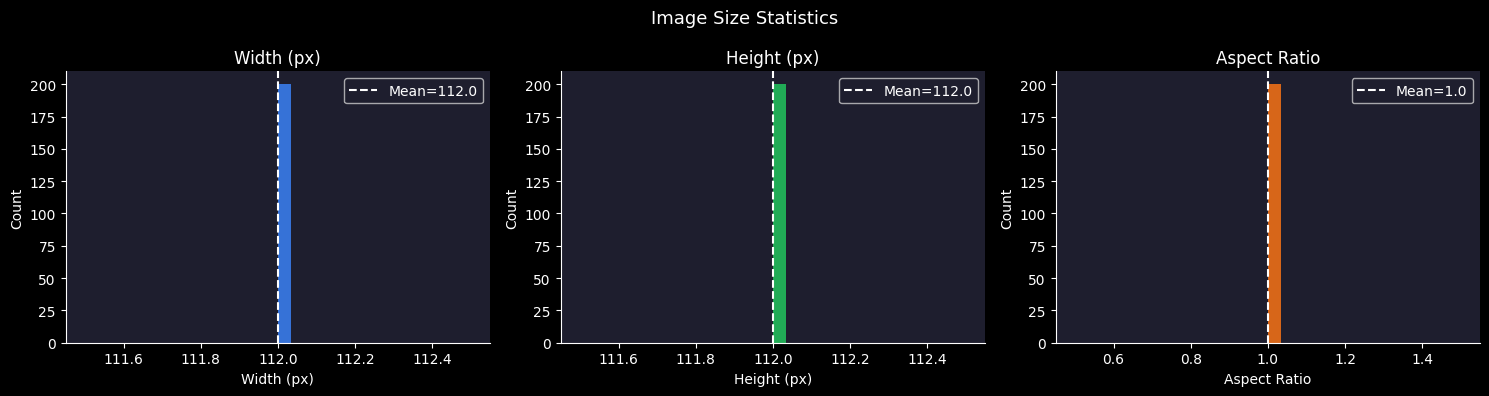

Width  — mean:112, std:0
Height — mean:112, std:0


In [7]:
sample_paths = df.sample(min(200, len(df)), random_state=42)["path"]
sizes = []
for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        sizes.append({"width": w, "height": h, "aspect": w/h})

sizes_df = pd.DataFrame(sizes)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Image Size Statistics", fontsize=13, color="white")

for ax, col, label, color in [
    (axes[0], "width",  "Width (px)",  "#3b82f6"),
    (axes[1], "height", "Height (px)", "#22c55e"),
    (axes[2], "aspect", "Aspect Ratio","#f97316"),
]:
    ax.hist(sizes_df[col], bins=30, color=color, alpha=0.85, edgecolor="none")
    ax.axvline(sizes_df[col].mean(), color="white", linestyle="--", linewidth=1.5,
               label=f"Mean={sizes_df[col].mean():.1f}")
    ax.set_title(label, color="white"); ax.set_xlabel(label, color="white")
    ax.set_ylabel("Count", color="white"); ax.legend(facecolor="#1e1e2e", labelcolor="white")
    ax.set_facecolor("#1e1e2e"); ax.tick_params(colors="white")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR/"04_image_sizes.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Width  — mean:{sizes_df['width'].mean():.0f}, std:{sizes_df['width'].std():.0f}")
print(f"Height — mean:{sizes_df['height'].mean():.0f}, std:{sizes_df['height'].std():.0f}")

## 6. Analisis Pixel Intensity per Kelas

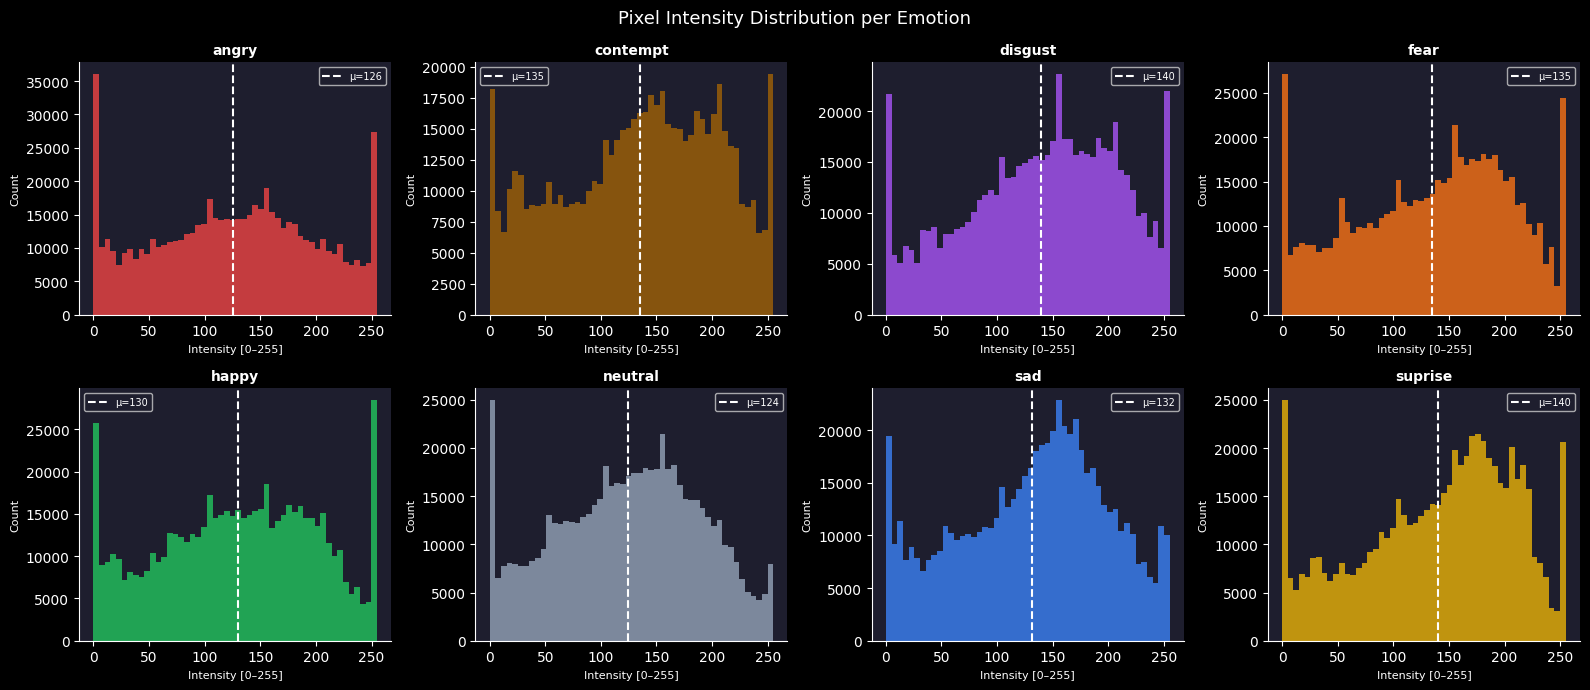

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for idx, emo in enumerate(EMOTION_CLASSES):
    subset = train_df[train_df["emotion"]==emo].head(50)
    all_pixels = []
    for _, row in subset.iterrows():
        img = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.extend(img.flatten().tolist())

    if all_pixels:
        axes[idx].hist(all_pixels, bins=50, color=COLORS[idx], alpha=0.8, edgecolor="none")
        axes[idx].set_title(emo, color="white", fontsize=10, fontweight="bold")
        axes[idx].set_xlabel("Intensity [0–255]", color="white", fontsize=8)
        axes[idx].set_ylabel("Count", color="white", fontsize=8)
        axes[idx].set_facecolor("#1e1e2e"); axes[idx].tick_params(colors="white")
        axes[idx].axvline(np.mean(all_pixels), color="white", linewidth=1.5, linestyle="--",
                          label=f"μ={np.mean(all_pixels):.0f}")
        axes[idx].legend(fontsize=7, facecolor="#1e1e2e", labelcolor="white")
        axes[idx].spines["top"].set_visible(False); axes[idx].spines["right"].set_visible(False)

plt.suptitle("Pixel Intensity Distribution per Emotion", fontsize=13, color="white")
plt.tight_layout()
plt.savefig(SAVE_DIR/"05_pixel_intensity.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## 7. Ringkasan EDA

In [9]:
print("="*60)
print("📊 EDA SUMMARY")
print("="*60)
print(f"Total samples : {len(df):,}")
for split in SPLITS:
    n = len(df[df["split"]==split])
    print(f"  {split:<14}: {n:,}")
print(f"\nKelas (8)     : {', '.join(EMOTION_CLASSES)}")
print(f"\nTrain class distribution:")
for emo, cnt in train_counts.items():
    bar = "█" * int(cnt / 50)
    print(f"  {emo:<12}: {cnt:>6,}  {bar}")
print(f"\nImbalance ratio : {imbalance_ratio:.2f}x")
print(f"Recommendation  : {'WeightedRandomSampler + augmentation diperlukan' if imbalance_ratio > 2 else 'Cukup seimbang'}")
print(f"\n✅ Semua plot disimpan di: {SAVE_DIR}")

📊 EDA SUMMARY
Total samples : 75,914
  train         : 64,000
  validation    : 8,341
  test          : 3,573

Kelas (8)     : angry, contempt, disgust, fear, happy, neutral, sad, suprise

Train class distribution:
  angry       :  8,000  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  contempt    :  8,000  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  disgust     :  8,000  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  fear        :  8,000  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  happy       :  8,000  █████████████████████